In [2]:
#example plot postsynaptic Ca2+ and synaptic efficacy in simple model   Fig1

import os
import sys
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib as mpl
from scipy import integrate
import math
from scipy.integrate import odeint
from multiprocessing import Process
import multiprocessing
from scipy import interpolate
from tqdm import tqdm
from numba import jit,  njit, i8, f8

from collections import deque
import itertools
import numpy as np

from datetime import datetime

import pandas as pd
fs = 20
fs_l = 15

In [4]:
# constant value and functions
rho_star = 0.5
zeta = 1

beta = 0.5
b=  5
g_nmdar = 0.0138403
g_cav_s = 0.050580


a_ca = 0.5
x_a = 34.8
x_tau = 0.2
s_a = 5
s_tau = 10
Vca = 120     # spike threshold [mV]
vrest = -70 # reset potential [mV]
area = 0.02

@jit(i8[:](f8[:], i8,i8,f8,f8[:], f8[:],f8,f8,i8,i8, f8,f8,f8,f8,i8))
def Solvers(init, Lt, offset, dt, mp_pre, mp_post, cpre_r, cpost_r, sum_p, sum_d, th_p, th_d, tau_ca_pre, tau_ca_post, solver):
    th_p = th_p #1.0871859
    th_d = th_d #0.65795
#     gp= gp #1454.49501
#     gd= gd #325.078706
    tau_ca_pre=tau_ca_pre #25
    tau_ca_post= tau_ca_post# 26.68402
#     sig=sig #2.03806
#     tau_s=tau_s #145447
    
    rho_star = 0.5
    zeta = 1
    area = 0.02

    beta = 0.5
    b=  5
    g_nmdar = 0.0138403
    g_cav_s = 0.050580

    a_ca = 0.5
    x_a = 34.8
    x_tau = 0.2
    s_a = 5
    s_tau = 10
    Vca = 120     # spike threshold [mV]
    vrest = -70 # reset potential [mV]

        
    
    def dAlldt(init, mp_pre, mp_post, it, cpre_r, cpost_r):
        
#         def nmda_f(v):
#             return 1.0 / (1.0 + np.exp(-(v-20)/2.0))
  
#         def inf_m(v):
#             return 1.0 / (1.0 + np.exp(-(v+20)/9))
        x = init[0]
        s = init[1]
        cpre = init[2]
        cpost = init[3]
        ca = cpre + cpost
        nmda_f = 1.0 / (1.0 + np.exp(-(mp_pre[it]-20)/2.0))
        
        dxdt = (x_a * nmda_f - x/x_tau)
        dsdt = (s_a * x * (1-s) - s/s_tau)
        i_nmda = (g_nmdar * s * (vrest-Vca))*cpre_r
        
        inf_m=1.0 / (1.0 + np.exp(-(mp_post[it]+20)/9))
        
        i_vdcc_s = (g_cav_s * (inf_m)**2 * (mp_post[it]-Vca))*cpost_r
        dcpre = (- (a_ca * (i_nmda))- cpre/tau_ca_pre)
        dcpost = (- (a_ca * (i_vdcc_s)*10*area) - cpost/tau_ca_post)
        dcadt =  dcpre + dcpost 
        ode = np.array([dxdt,dsdt, dcpre, dcpost])
        return ode
    
    for it in range(Lt):
        if it==0:
            continue
        cpre = init[2]
        cpost = init[3]
        ca = cpre + cpost


        if ca > th_p and it >= offset/dt:
            C_th_p = 1
            sum_p += 1
        else:
            C_th_p=0

        if ca > th_d and it >= offset/dt:
            C_th_d = 1
            sum_d += 1
        else:
            C_th_d = 0
        # 4th order Runge-Kutta 法
        if solver == 1:
            k1 = dt*dAlldt(init, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            k2 = dt*dAlldt(init + 0.5*k1, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            k3 = dt*dAlldt(init + 0.5*k2, mp_pre, mp_post,it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            k4 = dt*dAlldt(init + k3, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
            init = init + (k1 + 2*k2 + 2*k3 + k4) / 6
            # 陽的 Euler 法
        elif solver == 0:
            init = init + dt*dAlldt(init, mp_pre, mp_post, it, cpre_r, cpost_r, th_p, th_d, tau_ca_pre, tau_ca_post)
    
    return np.array([sum_p, sum_d])

/tmp/ipykernel_183049/1382415187.py:21: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @jit(i8[:](f8[:], i8,i8,f8,f8[:], f8[:],f8,f8,i8,i8, f8,f8,f8,f8,i8))


In [29]:

# simple 1Hz spikes -> MP
def gen_spikes(T, off, dt, n, interval,lag):

        spikes= np.zeros((2,int((T)/dt)))
        
        for i in range(n):
          
            if int(off/dt)+i*int(interval/dt) < int((T+off)/dt):
                spikes[0][int(off/dt)+i*int(interval/dt)] = 1
            if int(off/dt)+i*int(interval/dt) + int(lag/dt) < int((T+off)/dt):
                spikes[1][int(off/dt)+i*int(interval/dt) + int(lag/dt)]=1
       
        return spikes
    
def sp_to_mp_2(spikes, T, off ,peak, fx,fy, lx,ly, vrest):
    Lt = int((T)/dt)
    pre_x = np.arange(0,Lt,1)* spikes[0]
    pre_y = spikes[0]*peak
    post_x = np.arange(0,Lt,1)* spikes[1]
    post_y = spikes[1]*peak
    for m,j in enumerate(spikes[0]):
        if j==1:
            #if m+10 < spikes.shape[1]-2*off/dt:
                pre_x[m+lx]=pre_x[m] + lx
                pre_y[m+lx]= ly
            #if m-36 >=off/dt:
                pre_x[m+fx]=pre_x[m] + fx
                pre_y[m+fx]= fy

    for m,j in enumerate(spikes[1]):
        if j==1:
            #if m+10 < spikes.shape[1]-2*off/dt:#10000
                post_x[m+lx]=post_x[m] + lx
                post_y[m+lx]= ly
            #if m-36 >=off/dt:
                post_x[m+fx]=post_x[m] +fx
                post_y[m+fx]= fy
                

    pre_x_a = np.take(pre_x, np.nonzero(pre_x)[0])
    pre_y_a = np.take(pre_y, np.nonzero(pre_y)[0])
    post_x_a = np.take(post_x, np.nonzero(post_x)[0])
    post_y_a = np.take(post_y, np.nonzero(post_y)[0])

    af = (peak-fy)/(0-fx)
    xf_pre = int(pre_x_a[0]-(pre_y_a[0]-vrest)/af)
    xl_pre = int(pre_x_a[-1]+int(3/dt))  #3ms で過分極から戻る
    xf_post = int(post_x_a[0]-(post_y_a[0]-vrest)/af)
    xl_post = int(post_x_a[-1]+int(3/dt))
    pre_x_a = np.insert(pre_x_a,0,xf_pre)
    pre_x_a = np.append(pre_x_a,xl_pre)
    pre_y_a = np.insert(pre_y_a,0,vrest)
    pre_y_a = np.append(pre_y_a,vrest)
    post_x_a = np.insert(post_x_a,0,xf_post)
    post_x_a = np.append(post_x_a,xl_post)
    post_y_a = np.insert(post_y_a,0,vrest)
    post_y_a = np.append(post_y_a,vrest)

    x_latent_post = np.arange(min(post_x_a), max(post_x_a)+1, 1).astype("int32")
    x_latent_pre = np.arange(min(pre_x_a), max(pre_x_a)+1, 1).astype("int32")
    
     #ip1 = ["最近傍点補間", lambda x, y: interpolate.interp1d(x, y, kind="nearest",  fill_value="extrapolate")]
    ip2 = ["線形補間", lambda x, y: interpolate.interp1d(x,y,fill_value="extrapolate")]
    for method_name, method in [ip2]:
       # print(method_name)
        fitted_curve_pre = method(pre_x_a, pre_y_a)
        fitted_curve_post = method(post_x_a, post_y_a)
    middle_pre = fitted_curve_pre(x_latent_pre)
    middle_post = fitted_curve_post(x_latent_post)

    first_pre = np.ones(x_latent_pre[0])*vrest
    last_pre = np.ones(Lt-1-x_latent_pre[-1])*vrest
    first_post = np.ones(x_latent_post[0])*vrest
    last_post = np.ones(Lt-1-x_latent_post[-1])*vrest
    mp_pre = np.append(first_pre,middle_pre).astype("float64")
    mp_pre = np.append(mp_pre,last_pre).astype("float64")
    mp_post = np.append(first_post,middle_post).astype("float64")
    mp_post = np.append(mp_post,last_post).astype("float64")
   
    return mp_pre, mp_post


class area_gd:
    def __init__(self, pars, T, offset, dt, cpre_r, cpost_r, solvers = 0):
        self.T = T
        self.offset = offset
        self.dt = dt
        self.presum_p = 0
        self.presum_d = 0
        self.postsum_p = 0
        self.postsum_d = 0 
        self.init = np.array([0.01,0.01,0,0])
        self.tc = 0
        self.th_p = pars["th_p"]
        self.th_d = pars["th_d"]
        self.gp= pars["gp"]
        self.gd= pars["gd"]
        self.tau_ca_pre =    pars["tau_ca_pre"] 
        self.tau_ca_post =   pars["tau_ca_post"]
        self.sig= pars["sig"] 
        self.tau_s = pars["tau_s"]
        self.pars = pars
        self.sol_num = solvers
        self.cpre_r = cpre_r
        self.cpost_r = cpost_r
        self.area=0.02

    def dAlldt_area(self, init, mp_pre, mp_post, it):

        x = init[0]
        s = init[1]
        cpre = init[2]
        cpost = init[3]
       # print("cpost", cpost.shape)
        ca = cpre + cpost#init[4]
    #     print("mppres", mp_pres[:,it].shape)
    #     print("x", x.shape)
        dxdt = (x_a * self.nmda_f0(mp_pre[it]) - x/x_tau)
        dsdt = (s_a * x * (1-s) - s/s_tau)

        i_nmda = (g_nmdar * s * (vrest-120))*self.cpre_r
        i_vdcc_s = (g_cav_s * (self.inf_m0(mp_post[it]))**2 * (mp_post[it]-Vca))*self.cpost_r

        dcpre = (- (a_ca * (i_nmda))- cpre/self.tau_ca_pre)
        dcpost = (- (a_ca * (i_vdcc_s)*10*self.area) - cpost/self.tau_ca_post)
       # dcpost = np.tile(dcpost, NE).reshape(-1,1)
        dcadt =  dcpre + dcpost #(- a_ca * (i_nmda + i_vdcc_s) - ca/tau_ca_syn)
   
        ode = np.array([dxdt,dsdt, dcpre, dcpost])
        return ode
    
    def Solvers_area(self, func, init,  mp_pre, mp_post,it, solver=0):
        cpre = init[2]
        cpost = init[3]
        if cpre  > self.th_p and it > self.offset/self.dt:
            self.presum_p +=1
        if cpre  > self.th_d and it > self.offset/self.dt:
            self.presum_d +=1
        if cpost  > self.th_p and it > self.offset/self.dt: 
            self.postsum_p +=1
        if cpost  > self.th_d and it > self.offset/self.dt:
            self.postsum_d +=1
        # 4th order Runge-Kutta 法
        if solver == 1:
            k1 = dt*func(init, mp_pre, mp_post, it)
            k2 = dt*func(init + 0.5*k1, mp_pre, mp_post, it)
            k3 = dt*func(init + 0.5*k2, mp_pre, mp_post,it)
            k4 = dt*func(init + k3, mp_pre, mp_post, it)
            return init + (k1 + 2*k2 + 2*k3 + k4) / 6
            # 陽的 Euler 法
        elif solver == 0:
            return init + dt*func(init, mp_pre, mp_post, it)
        else:
            return None
    
    def run_ode_np_area(self, mp_pre, mp_post):
        Lt = int((self.T)/self.dt)


        X_arr = np.zeros((4, Lt))
        X_arr[:,0] = self.init

        for it in range(Lt):

            init = self.Solvers_area(self.dAlldt_area, self.init,  mp_pre, mp_post, it, self.sol_num)
            self.init = init
            #print("init", init.shape)
            X_arr[:,it] = init

        init_t = int(self.offset/self.dt)

        cpre_amp = np.max(X_arr[2][init_t:])
        cpost_amp = np.max(X_arr[3][init_t:])
        
        return self.pars, X_arr[2,:], X_arr[3,:]
        
    def nmda_f0(self, v):
        return 1.0 / (1.0 + np.exp(-(v-20)/2.0))

    def inf_m0(self, v):
        return 1.0 / (1.0 + np.exp(-(v+20)/9))


    
def Solvers2(pars, func, init , offset, dt, mp_pre, mp_post,it, cpre_r, cpost_r, sum_p, sum_d, solver=0):
    cpre = init[2]
    cpost = init[3]
    ca = cpre + cpost
    th_p = pars["th_p"]
    th_d = pars["th_d"]
    
    if ca > th_p and it >= offset/dt:
        C_th_p = 1
        sum_p += 1
    else:
        C_th_p=0

    if ca > th_d and it >= offset/dt:
        C_th_d = 1
        sum_d += 1
    else:
        C_th_d = 0
    # 4th order Runge-Kutta 法
    if solver == 1:
        k1 = dt*func(pars, init, mp_pre, mp_post , offset, dt, it, cpre_r, cpost_r)
        k2 = dt*func(pars, init + 0.5*k1, mp_pre, mp_post, offset, dt,it, cpre_r, cpost_r)
        k3 = dt*func(pars, init + 0.5*k2, mp_pre, mp_post,offset, dt,it, cpre_r, cpost_r)
        k4 = dt*func(pars, init + k3, mp_pre, mp_post,offset, dt, it, cpre_r, cpost_r)
        return init + (k1 + 2*k2 + 2*k3 + k4) / 6, sum_p, sum_d
        # 陽的 Euler 法
    elif solver == 0:
        return init + dt*func(init, mp_pre, mp_post,  offset, dt,it, cpre_r, cpost_r), sum_p, sum_d
    else:
        return None

# pars,lag, test_T, offset, dt, cpre_r, cpost_r, vpre, vpost,  syn_c_dic
def run_ode_lr(lag, T, offset, dt, cpre_r, cpost_r, mp_pre, mp_post,  syn_c_dic, gp, gd, th_p, th_d, tau_ca_pre, tau_ca_post, sig, taus):

    

    Lt=int((T)/dt)
    
    peak =13  #12.692
    fx,fy = int(-0.8/dt),-68  #down to up
    lx,ly = int(0.8/dt), -76  #down
    vrest = -70

    off = 200 #ms 
    n=3
    interval = 1000 #ms
    stim_T = n *interval
    
    spikes_stim = gen_spikes(stim_T,off,dt,n,interval,lag)
    mp_pre, mp_post =sp_to_mp_2(spikes_stim, stim_T,off, peak, fx, fy, lx, ly, vrest)
  

    init_t = 0
    cpre = 0
    cpost = 0
#     ca = 0
    x_n= 0.01
    s_n = 0.01
    
    init = np.array([x_n,s_n,cpre,cpost])
    
    sum_p = 0
    sum_d = 0
    
   
    sums = Solvers(init, Lt, offset, dt, mp_pre, mp_post, cpre_r, cpost_r, 
                                  sum_p, sum_d,th_p, th_d, tau_ca_pre, tau_ca_post, 1)
    sum_p = sums[0]
    sum_d = sums[1]
#     print("gd",gd)
#     print("sum_p", sum_p)
#     print("sum_d", sum_d)
#     ap = sum_p*60/(60000/dt)
#     ad = sum_d*60/(60000/dt)
    ap = sum_p*60/(60000/dt)
    ad = sum_d*60/(60000/dt)
#     print("ap",ap*gp)
#     print("ad",ad*gd)
    
    try:
        rho_b = gp*ap/(gp*ap+gd*ad)
        sig_r = np.sqrt(sig*sig*(ap+ad)/(gp*ap+gd*ad))
        tau_eff = (tau_s/dt)/(gp*ap+gd*ad)
        sig_r0 = 0
        
        u= U_p(0,rho_b,rho_star,sig_r,tau_eff,60,interval/dt)
        d = D_p(1,rho_b,rho_star,sig_r,tau_eff,60,interval/dt)
        #print("u",u)
#         u0= U_p(0,rho_b,s_star,sig_r0,tau_eff,n,interval)
#         d0 = D_p(1,rho_b,s_star,sig_r0,tau_eff,n,interval)
        
        syn_c = ((1-u)*beta+d*(1-beta)+b*(u*beta+(1-d)*(1-beta)))/(beta+(1-beta)*b)
#         syn_c0 = ((1-u0)*beta+d0*(1-beta)+b*(u0*beta+(1-d0)*(1-beta)))/(beta+(1-beta)*b)
        if syn_c<0:    
            syn_c=0
    except ZeroDivisionError as e:
        print("zerodiv")
        rho_b = 0.5
        #sig_r = 0
        #tau_eff = tau_s*1000/(gp*ap+gd*ad) 
        syn_c = 1.0
#         syn_c0=1.0
    syn_c_dic[int(lag)] = syn_c
#     print("lag {}, syn_c {}".format(lag, syn_c))
    return syn_c, cpre, cpost #, syn_c0        
            
def run_ode_lr2(pars,lag, T, offset, dt, cpre_r, cpost_r, mp_pre, mp_post,  syn_c_dic):

    tau_ca_pre  = pars['tau_ca_pre']
    tau_ca_post  = pars['tau_ca_post']
    tau_s  = pars['tau_s'] 
    sig = pars['sig']
    th_d, th_p = pars['th_d'], pars['th_p']
    gd, gp = pars['gd'], pars['gp']
    
    Lt = int((T)/dt)
    
    peak =13  #12.692
    fx,fy = int(-0.8/dt),-68  #down to up
    lx,ly = int(0.8/dt), -76  #down
    vrest = -70

    off = 200 #ms 
    n=62
    interval = 1000 #ms
    stim_T = n *interval
    
    spikes_stim = gen_spikes(stim_T,off,dt,n,interval,lag)
    mp_pre, mp_post =sp_to_mp_2(spikes_stim, stim_T,off, peak, fx, fy, lx, ly, vrest)

    cpre = 0
    cpost = 0

    x_n= 0.01
    s_n = 0.01
    rho_c = 0.5
    
    init = np.array([x_n,s_n,cpre,cpost, rho_c])
    
    X_arr = np.zeros((5,Lt))
    X_arr[:,0] = init
    
    sum_p = 0
    sum_d = 0
    
    for it in tqdm(range(Lt)):
        if it ==0:
            continue
        init, sum_p, sum_d= Solvers2(pars, dAlldt2, init, offset,  dt, mp_pre, mp_post,it, cpre_r, cpost_r,  sum_p, sum_d, 1)
        X_arr[:,it] = init
   
#     print("sum_p", sum_p)
#     print("sum_d", sum_d)
    
    
    ap = sum_p/(60000/dt)
    ad = sum_d/(60000/dt)
#     print("gp*ap", gp*ap)
#     print("gd*ad", gd*ad)
    
    try:
        rho_b = gp*ap/(gp*ap+gd*ad)
        sig_r = np.sqrt(sig*sig*(ap+ad)/(gp*ap+gd*ad))
        tau_eff = (tau_s/dt)/(gp*ap+gd*ad)
        sig_r0 = 0
        
        u= U_p(0,rho_b,rho_star,sig_r,tau_eff,60,1000/dt)
        d = D_p(1,rho_b,rho_star,sig_r,tau_eff,60,1000/dt)
        #print("u",u)
#         u0= U_p(0,rho_b,s_star,sig_r0,tau_eff,n,interval)
#         d0 = D_p(1,rho_b,s_star,sig_r0,tau_eff,n,interval)
        
        syn_c = ((1-u)*beta+d*(1-beta)+b*(u*beta+(1-d)*(1-beta)))/(beta+(1-beta)*b)
#         syn_c0 = ((1-u0)*beta+d0*(1-beta)+b*(u0*beta+(1-d0)*(1-beta)))/(beta+(1-beta)*b)
        if syn_c<0:    
            syn_c=0
    except ZeroDivisionError as e:
        print("zerodiv")
        rho_b = 0.5
        #sig_r = 0
        #tau_eff = tau_s*1000/(gp*ap+gd*ad) 
        syn_c = 1.0
#         syn_c0=1.0
    syn_c_dic[int(lag)] = syn_c
    print("lag {}, syn_c {}".format(lag, syn_c))
    return X_arr, syn_c
    
def dAlldt2(pars, init, mp_pre, mp_post, offset, dt, it, cpre_r, cpost_r):

        x = init[0]
        s = init[1]
        cpre = init[2]
        cpost = init[3]
        rho=init[4]
        ca = cpre + cpost#init[4]

        dxdt = (x_a * nmda_f(mp_pre[it]) - x/x_tau)
        dsdt = (s_a * x * (1-s) - s/s_tau)
        i_nmda = (g_nmdar * s * (vrest-120))*cpre_r
        i_vdcc_s = (g_cav_s * (inf_m(mp_post[it]))**2 * (mp_post[it]-Vca))*cpost_r
        dcpre = (- (a_ca * (i_nmda))- cpre/tau_ca_pre)
        dcpost = (- (a_ca * (i_vdcc_s)*10*area) - cpost/tau_ca_post)
       # dcpost = np.tile(dcpost, NE).reshape(-1,1)
        dcadt =  dcpre + dcpost #(- a_ca * (i_nmda + i_vdcc_s) - ca/tau_ca_syn)
        
        if it >= offset/dt: 
            if ca > th_p:
                C_th_p=1
            else:
                C_th_p=0

            if ca > th_d:
                C_th_d=1
            else:
                C_th_d=0
            Noise = sig*np.sqrt(tau_s)*np.sqrt(C_th_d+C_th_p)*np.random.normal(0,zeta,1)[0]*np.sqrt(3.5/dt)
            drho=  ((-rho*(1-rho)*(rho_star-rho)+(gp*(1-rho)*C_th_p-gd*rho*C_th_d+Noise))/tau_s)
        else:
            drho = 0

        ode = np.array([dxdt,dsdt, dcpre, dcpost, drho])
        #ode = np.array([dxdt, dsdt, dcpre, dcpost, dcadt, drho])
        return ode
    
from scipy import integrate
import math
def erf(x):
   # 2/np.sqrt(np.pi)
    y=lambda t: math.exp(-t*t)
    integ = integrate.quad(y, 0, x)
    v =2/np.sqrt(np.pi)*integ[0]
    #np.linspace = (0,x,1000)
    #print("erf", v)
    return v

def U_p(rho_0,rho_b,rho_star,sig_r,tau_eff,n,interval):
    x=(rho_star-rho_b+(rho_b-rho_0)*np.exp(-n*interval/tau_eff))/(np.sqrt(sig_r*sig_r*(1-np.exp(-2*n*interval/tau_eff))))
    eul = erf(-x)
    u= 1/2*(1+eul)
    #print("u_x", x)
    return u

def D_p(rho_0,rho_b,rho_star,sig_r,tau_eff,n,interval):
    x=(rho_star-rho_b+(rho_b-rho_0)*np.exp(-n*interval/tau_eff))/(np.sqrt(sig_r*sig_r*(1-np.exp(-2*n*interval/tau_eff))))
    eul = erf(-x)
    d= 1/2*(1-eul)
    #print("d_x", x)
    return d



def fitting_curve(lr_li, lag_li, lag_step, syn_c_sorted, amp, tau,dx_li):
    esqs = np.zeros(4)
    dxs = np.zeros(4)
    
    esqs[0], dxs[0] = gaus_fit(lag_li, syn_c_sorted, amp, amp, tau,dx_li)
    esqs[1], dxs[1] = gaus_fit(lag_li, syn_c_sorted, -amp, -amp, tau,dx_li)
    esqs[2], dxs[2] = gaus_fit(lag_li, syn_c_sorted, -amp, amp, tau,dx_li)
    esqs[3], dxs[3] = gaus_fit(lag_li, syn_c_sorted, amp, -amp, tau,dx_li)
    
    min_esq = np.min(esqs)
   # print("min_residual", min_esq)
    min_dx = dxs[np.argmin(esqs)]
    lr_index = np.argmin(esqs)
    #print(lr_li[lr_index])
    return lr_index, min_esq, min_dx

def gaus_fit(lag_li, syn_c_sorted, a, b, tau, dx_li):
    esq_li = []
    for dx in dx_li:
    
        xl = np.arange(lag_li[0], -dx*lag_step, lag_step)
        xr = np.arange(-dx*lag_step, lag_li[-1]+lag_step/2, lag_step)
    
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    
        y=np.append(yl, yr)

        y=y+1
        esq = np.sum((syn_c_sorted-y)*(syn_c_sorted-y))
        esq_li.append(esq)
    min_esq = np.min(esq_li)
    min_dx = dx_li[np.argmin(esq_li)]
    return min_esq, min_dx


def repro_wave(lr_index, lag_li, sync_li, lag_step, amp, tau, dx, gauss=True):
    xl = np.arange(lag_li[0], -dx*lag_step, lag_step)
    xr = np.arange(-dx*lag_step, lag_li[-1]+lag_step/2, lag_step)
    if lr_index == 0:
        a = amp
        b = amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    if lr_index == 1:
        a = -amp
        b= -amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    
    if lr_index == 2: 
        a = -amp
        b= amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)
    
    
    if lr_index == 3:
        a = amp
        b= -amp
        yl = a*np.exp(-(xl+dx*lag_step)**2/tau**2)
        yr = b*np.exp(-(xr+dx*lag_step)**2/tau**2)

    y=np.append(yl, yr)
    y=y+1


    plt.figure(figsize=(8, 8))
    plt.plot(lag_li, sync_li) #label = "data")
    
    if gauss==True:
        plt.plot(lag_li, y, linestyle = "dashed") #, label="fitted")
   
    fs = 20
    fs_l= 15
    plt.xlabel('Time lag(ms)',fontsize = fs)
    plt.ylabel("Synaptic change", fontsize = fs)
    plt.xlim(-150, 150)
    plt.ylim(0.2, 1.8)
    yc=np.ones(len(lag_li))*1.0
    plt.plot(lag_li, yc, color="gray", alpha = 0.6)
    plt.xticks(fontsize = fs_l)
    plt.yticks(fontsize = fs_l)
#     ax = plt.gca()
     
#     ax.axes.xaxis.set_ticklabels([])
#     ax.axes.yaxis.set_ticklabels([])
    # plt.legend(fontsize = fs)
    plt.show()
    
def random_samp(relm):
    x=np.random.rand(1)*(relm[1]-relm[0])+relm[0]
    return x[0]

def set_lr_params(th_p_r, th_d_r, gp_r, gd_r, tau_ca_pre_r, tau_ca_post_r, sig_r, tau_s_r):
    th_p=random_samp(th_p_r)
    th_d= random_samp(th_d_r)
    gp=random_samp(gp_r)
    gd=random_samp(gd_r)

    tau_ca_pre = random_samp(tau_ca_pre_r)
    tau_ca_post = random_samp(tau_ca_post_r)
    sig =random_samp(sig_r)
    
    tau_s = random_samp(tau_s_r)
    
    
    pars = {}
    

    pars["th_p"]  =1.1624237569297997
    pars["th_d"] = 0.702631293634435
    pars["gp"] =   570.0727831475216
    pars["gd"] = 161.1929938555061
    pars["tau_ca_pre"] =  36.6854713083550#44.5266041777
    pars["tau_ca_post"] = 20.3582951509#22.7902772483692
    pars["sig"] =   1.98768496996675#2.0967071238379 #sig
    pars["tau_s"] =270275.77154806757# 188587.743550827#tau_s

    #print(pars)
    return pars

def nmda_f(v):
        return 1.0 / (1.0 + np.exp(-(v-20)/2.0))

def inf_m(v):
    return 1.0 / (1.0 + np.exp(-(v+20)/9))

In [ ]:
#obtain analytical results of synaptic changes

th_d_r=[0.06, 1.6]
th_p_r=[0.06, 1.6]
gp_r = [50,5000]
gd_r=[50,10000]
tau_ca_pre_r = [1,100]
tau_ca_post_r = [1,100]
sig_r = [0.5, 35]
tau_s_r = [2.5*1000, 2500*1000]


lr_p = "a0.7t50"
savedir ="../simple_model/"
lr_li = ["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
amp = 0.7
tau = 50
th = 0.25
dx_li =[0] #np.arange(-3,3,1, dtype = "int8") 
    
NE = 1
test_T=62000 #offset including
offset=2000
T = 62000 #offset including

dt = 0.1
lag_step=10
lag_li = np.arange(-160, 170, lag_step)

peak =13  
fx,fy = int(-0.8/dt),-68  #down to up
lx,ly = int(0.8/dt), -76  #down
vrest = -70

off = 200 #ms 
n=62
interval = 1000 #ms
stim_T = n *interval

colors =["orange", "blue", "magenta", "green" ]
cmap_li =["YlOrBr_r", "Blues_r", "PuRd_r", "Greens_r" ]



N=1

for lr_in in range(4):
    if lr_in != 0:
        continue
#     lr_in = 0
    # pd_lr = pd_params[pd_params["lr"]==lr_in]
    pd_lr = pd.read_excel(savedir+lr_li[lr_in]+"_"+lr_p+"_1000_ori.xlsx")

    if lr_in ==0:
        vmin = 0.9
        vmax = 1.7

    elif lr_in==1:
        vmin = 0.3
        vmax = 1.1
    else:
        vmin = 0.3
        vmax = 1.7

    fig = plt.figure(figsize=(6, 6))
    ax  = fig.add_axes((0.05, 0.15, 0.7, 0.7))

    min_esq_li=np.zeros(N)
    sync_li= []#np.zeros(N)

    for i in range(N):
            if i%100 == 0:
                print("i", i)

            if __name__ == "__main__":

#                 pd_param =pd_lr.iloc[i,0:8]
#                 pars = pd_param.to_dict()

                pars = set_lr_params(th_p_r, th_d_r, gp_r, gd_r, tau_ca_pre_r, tau_ca_post_r, sig_r, tau_s_r)
                cpre_r,cpost_r = 1,1
                lag=100
                spikes_stim = gen_spikes(stim_T,off,dt,n,interval,lag)
                vpre, vpost =sp_to_mp_2(spikes_stim, stim_T, off, peak, fx, fy, lx, ly, vrest)
                area_class = area_gd(pars, test_T, offset, dt,cpre_r, cpost_r, 1)
                pars, cpre_t, cpost_t = area_class.run_ode_np_area(vpre, vpost)
                cpre_r = 0.7/np.max(cpre_t[int(offset/dt):int(test_T/dt)])
                cpost_r = 1.4/np.max(cpost_t[int(offset/dt):int(test_T/dt)])

                tau_ca_pre  = pars['tau_ca_pre']
                tau_ca_post  = pars['tau_ca_post']
                tau_s  = pars['tau_s'] 
                sig = pars['sig']
                th_d, th_p = pars['th_d'], pars['th_p']
                gd, gp = pars['gd'], pars['gp']
    #             if gd > gd_r[1]:
    #                 continue
                results=[]
                manager = multiprocessing.Manager()
                syn_c_dic = manager.dict()
                for lag in lag_li:
                    fs=20
                    p = Process(target=run_ode_lr, args=(lag, T, offset, dt, cpre_r, cpost_r, vpre, vpost,  syn_c_dic,gp, gd, th_p, th_d, tau_ca_pre, tau_ca_post, sig, tau_s))
                 


                    p.start()
                    results.append(p)

                for p in results:
                    p.join()

                a = syn_c_dic.items()
                print("syncdic", a)
                new_dic = sorted(a)
                syn_c_sorted = np.array([i[1] for i in new_dic])
                
repro_wave(lr_index, lag_li, syn_c_sorted, lag_step, amp, tau, 0, gauss=False)
               

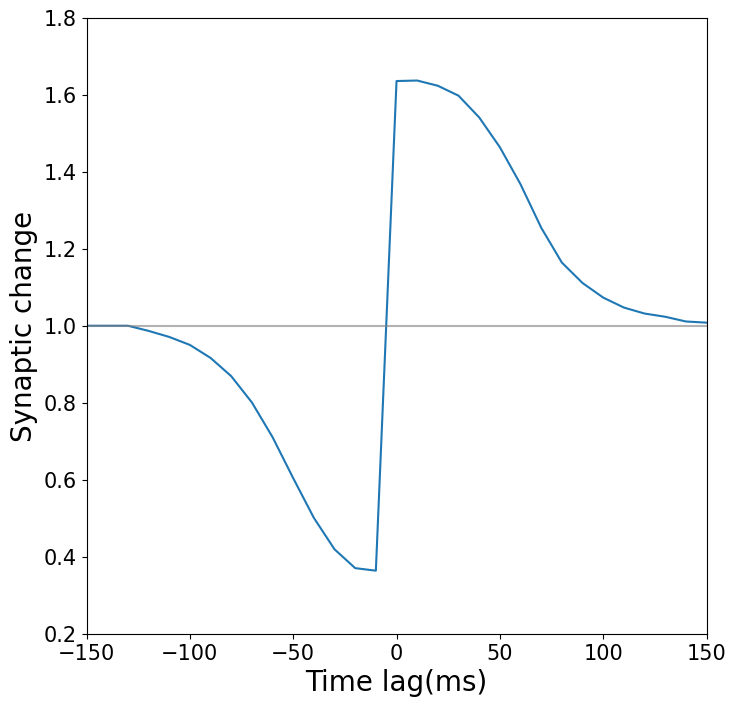

i 0


100%|█████████████████████████████████| 620000/620000 [01:17<00:00, 7994.10it/s]


lag 20, syn_c 1.6232553186385488


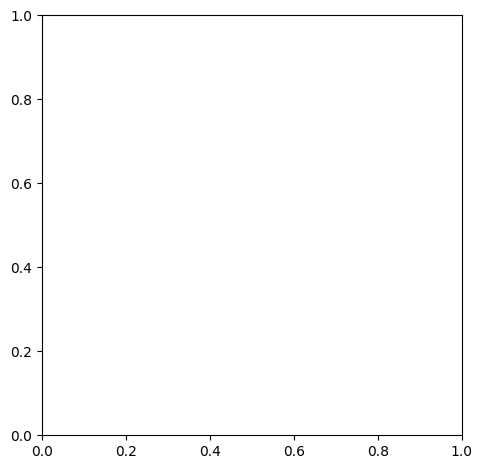

In [25]:
#calculate synaptic efficacy by lag time

th_d_r=[0.06, 1.6]
th_p_r=[0.06, 1.6]
gp_r = [50,5000]
gd_r=[50,10000]
tau_ca_pre_r = [1,100]
tau_ca_post_r = [1,100]
sig_r = [0.5, 35]
tau_s_r = [2.5*1000, 2500*1000]


lr_p = "a0.7t50"
savedir ="../simple_model/"
lr_li = ["Hebbian", "Anti-Hebbian", "STDP", "Anti-STDP"]
amp = 0.7
tau = 50
th = 0.25
dx_li =[0] #np.arange(-3,3,1, dtype = "int8") 
    
NE = 1
test_T=62000 #offset including
offset=2000
T = 62000 #offset including

dt = 0.1
lag_step=10
lag_li = [20]

peak =13  
fx,fy = int(-0.8/dt),-68  #down to up
lx,ly = int(0.8/dt), -76  #down
vrest = -70

off = 200 #ms 
n=62
interval = 1000 #ms
stim_T = n *interval

colors =["orange", "blue", "magenta", "green" ]
cmap_li =["YlOrBr_r", "Blues_r", "PuRd_r", "Greens_r" ]



N=1

for lr_in in range(4):
    if lr_in != 0:
        continue
#     lr_in = 0
    # pd_lr = pd_params[pd_params["lr"]==lr_in]
    pd_lr = pd.read_excel(savedir+lr_li[lr_in]+"_"+lr_p+"_1000_ori.xlsx")

    if lr_in ==0:
        vmin = 0.9
        vmax = 1.7

    elif lr_in==1:
        vmin = 0.3
        vmax = 1.1
    else:
        vmin = 0.3
        vmax = 1.7

    fig = plt.figure(figsize=(6, 6))
    ax  = fig.add_axes((0.05, 0.15, 0.7, 0.7))

    min_esq_li=np.zeros(N)
    sync_li= []#np.zeros(N)

    for i in range(N):
            if i%100 == 0:
                print("i", i)

            if __name__ == "__main__":

#                 pd_param =pd_lr.iloc[i,0:8]
#                 pars = pd_param.to_dict()

                pars = set_lr_params(th_p_r, th_d_r, gp_r, gd_r, tau_ca_pre_r, tau_ca_post_r, sig_r, tau_s_r)
                cpre_r,cpost_r = 1,1
                lag=100
                spikes_stim = gen_spikes(stim_T,off,dt,n,interval,lag)
                vpre, vpost =sp_to_mp_2(spikes_stim, stim_T, off, peak, fx, fy, lx, ly, vrest)
                area_class = area_gd(pars, test_T, offset, dt,cpre_r, cpost_r, 1)
                pars, cpre_t, cpost_t = area_class.run_ode_np_area(vpre, vpost)
                cpre_r = 0.7/np.max(cpre_t[int(offset/dt):int(test_T/dt)])
                cpost_r = 1.4/np.max(cpost_t[int(offset/dt):int(test_T/dt)])

                tau_ca_pre  = pars['tau_ca_pre']
                tau_ca_post  = pars['tau_ca_post']
                tau_s  = pars['tau_s'] 
                sig = pars['sig']
                th_d, th_p = pars['th_d'], pars['th_p']
                gd, gp = pars['gd'], pars['gp']
    #             if gd > gd_r[1]:
    #                 continue
                results=[]
#                 manager = multiprocessing.Manager()
                syn_c_dic = {}#manager.dict()
#                 syn_c_dic = manager.dict()
                for lag in lag_li:
                    fs=20
#                    
                    X_arr, syn_c = run_ode_lr2(pars,lag, T, offset, dt, cpre_r, cpost_r, vpre, vpost,  syn_c_dic)



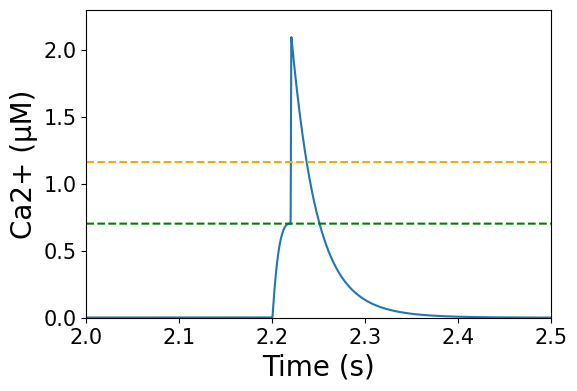

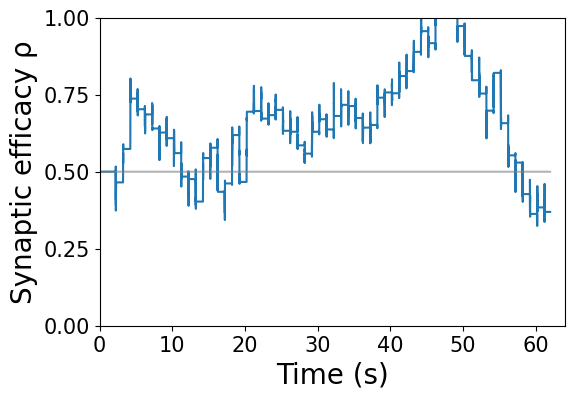

In [26]:
#plot graph postsynaptic Ca2+ and synaptic efficacy

fs = 20
fs_l = 15
x = np.arange(0, (T), dt)/1000
s = int(offset/1000)
e = int((offset + T)/1000)

plt.figure(figsize=(6, 4))
plt.yticks(np.arange(0,2.1,0.5))
plt.xticks(np.arange(2,2.6,0.1))
plt.plot(x, X_arr[2,:]+X_arr[3,:])
plt.ylim(0,2.3)
plt.xlim(2.0, 2.5)
plt.xlabel('Time (s)',fontsize = fs)
plt.ylabel("Ca2+ (μM)", fontsize = fs)

yp=np.ones(len(x))*pars["th_p"]
plt.plot(x, yp, linestyle = "dashed", color="orange")

yd=np.ones(len(x))*pars["th_d"]
plt.plot(x, yd, linestyle = "dashed", color="green")

plt.xticks(fontsize = fs_l)
plt.yticks(fontsize = fs_l)
# ax = plt.gca()
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])
plt.show()
# plt.savefig("Ca_+20")


plt.figure(figsize=(6, 4))

plt.yticks(np.arange(0,1.1,0.25))
plt.xticks(np.arange(0,65,10))

plt.plot(x, X_arr[4,:])
plt.ylim(0,1)
plt.xlim(0, e)
y=np.ones(len(x))*0.5
plt.plot(x,y,alpha=0.6,color="gray")

plt.xlabel('Time (s)',fontsize = fs)
plt.ylabel("Synaptic efficacy ρ", fontsize = fs)

plt.xticks(fontsize = fs_l)
plt.yticks(fontsize = fs_l)
# ax = plt.gca()
     
# ax.axes.xaxis.set_ticklabels([])
# ax.axes.yaxis.set_ticklabels([])
plt.show()
# plt.savefig("syn_effi_+20")